In [ ]:
import pandas as pd
import polars as pl

# Asegúrate de que la ruta sea correcta según dónde tienes tu notebook
ruta_archivo = "../data/raw/casen_2024.dta"

# Las variables que tú mismo seleccionaste
columnas_exploracion = [
    'folio', 'id_persona', 'region', 'expr', 
    'y27_preg', 'y24_preg', 'y24', 'v13', 'v15', 
    'o28a_hr', 'o28a_min', 'yautcorh', 'ytotcorh', 
    'ind_estado', 'pobreza_multi', 'lp'
]

print("1. Cargando datos desde el archivo Stata...")
df_pandas = pd.read_stata(ruta_archivo, columns=columnas_exploracion, convert_categoricals=False)

print("2. Convirtiendo a Polars...")
df = pl.from_pandas(df_pandas)

print("\n--- RESUMEN DE LA CARGA ---")
print(f"Total de registros (filas): {df.shape[0]}")
print(f"Total de variables (columnas): {df.shape[1]}")

# Mostramos una pequeña muestra para ver qué "forma" tienen los números
print("\nMuestra de los datos (primeras 3 filas):")
print(df.head(3))

1. Cargando datos desde el archivo Stata...
2. Convirtiendo a Polars...

--- RESUMEN DE LA CARGA ---
Total de registros (filas): 218367
Total de variables (columnas): 16

Muestra de los datos (primeras 3 filas):
shape: (3, 16)
┌───────────┬────────────┬────────┬──────┬───┬──────────┬────────────┬───────────────┬──────────┐
│ folio     ┆ id_persona ┆ region ┆ expr ┆ … ┆ ytotcorh ┆ ind_estado ┆ pobreza_multi ┆ lp       │
│ ---       ┆ ---        ┆ ---    ┆ ---  ┆   ┆ ---      ┆ ---        ┆ ---           ┆ ---      │
│ i32       ┆ i8         ┆ i8     ┆ i16  ┆   ┆ f64      ┆ i8         ┆ f64           ┆ f32      │
╞═══════════╪════════════╪════════╪══════╪═══╪══════════╪════════════╪═══════════════╪══════════╡
│ 100020301 ┆ 1          ┆ 13     ┆ 264  ┆ … ┆ 700000.0 ┆ 2          ┆ 0.0           ┆ 237094.0 │
│ 100020301 ┆ 2          ┆ 13     ┆ 264  ┆ … ┆ 700000.0 ┆ 2          ┆ 0.0           ┆ 237094.0 │
│ 100020401 ┆ 1          ┆ 13     ┆ 295  ┆ … ┆ 3.2535e6 ┆ 1          ┆ 0.0           ┆ 

In [ ]:
print("HOLA")

In [2]:
# --- CELDA 2: RADIOGRAFÍA DE DATOS (VALORES NULOS) ---

# Vamos a contar cuántos valores vacíos (null) tiene cada columna vital
resumen_vacios = df.select([
    pl.col("ytotcorh").is_null().sum().alias("Falta_Ingreso_Hogar"),
    pl.col("o28a_hr").is_null().sum().alias("Falta_Tiempo_Viaje"),
    pl.col("v15").is_null().sum().alias("Falta_Subsidio_Casa"),
    pl.col("y24").is_null().sum().alias("Falta_Subsidio_Agua")
])

print("--- CANTIDAD DE RESPUESTAS VACÍAS (De 218.367 personas) ---")
print(resumen_vacios)

# Veamos rápido cómo se distribuye el estado de las casas a nivel general
print("\n--- DISTRIBUCIÓN DEL ESTADO DE LA VIVIENDA (ind_estado) ---")
# 1 = Bueno, 2 = Aceptable, 3 = Malo
print(df.group_by("ind_estado").len().sort("ind_estado"))

--- CANTIDAD DE RESPUESTAS VACÍAS (De 218.367 personas) ---
shape: (1, 4)
┌─────────────────────┬────────────────────┬─────────────────────┬─────────────────────┐
│ Falta_Ingreso_Hogar ┆ Falta_Tiempo_Viaje ┆ Falta_Subsidio_Casa ┆ Falta_Subsidio_Agua │
│ ---                 ┆ ---                ┆ ---                 ┆ ---                 │
│ u32                 ┆ u32                ┆ u32                 ┆ u32                 │
╞═════════════════════╪════════════════════╪═════════════════════╪═════════════════════╡
│ 107                 ┆ 122933             ┆ 87152               ┆ 205687              │
└─────────────────────┴────────────────────┴─────────────────────┴─────────────────────┘

--- DISTRIBUCIÓN DEL ESTADO DE LA VIVIENDA (ind_estado) ---
shape: (3, 2)
┌────────────┬────────┐
│ ind_estado ┆ len    │
│ ---        ┆ ---    │
│ i8         ┆ u32    │
╞════════════╪════════╡
│ 1          ┆ 148351 │
│ 2          ┆ 45371  │
│ 3          ┆ 24645  │
└────────────┴────────┘


Falta_Tiempo_Viaje (122.933): Como sospechábamos antes, este número coincide exacto con los niños, jubilados y cesantes. Nos confirma que tenemos a unos 95.000 trabajadores activos listos para ser analizados.

Falta_Subsidio_Casa (87.152): ¿Por qué falta tanta gente aquí? Porque la pregunta es "¿Compró esta casa con subsidio?". A los que arriendan, viven de allegados o son ocupantes irregulares (tomas), el encuestador simplemente les salta esta pregunta.

In [6]:
# --- CELDA 3: EL CRUCE DE POBREZA, VIVIENDA Y SUBSIDIOS ---

print("Calculando el nivel de dependencia de subsidios estatales...")

# 1. Filtramos: Solo hogares con ingresos válidos e ignoramos los nulos en estado de vivienda
df_analisis = df.filter(
    (pl.col("ytotcorh").is_not_null()) & 
    (pl.col("ytotcorh") > 0) &
    (pl.col("ind_estado").is_not_null())
)

# 2. Creamos la variable "Porcentaje de Dependencia del Estado"
# (Ingreso Total - Ingreso que ganan por su trabajo) / Ingreso Total
df_analisis = df_analisis.with_columns(
    (((pl.col("ytotcorh") - pl.col("yautcorh").fill_null(0)) / pl.col("ytotcorh")) * 100).alias("dependencia_estatal_pct")
)

# Limpiamos posibles datos raros (porcentajes bajo 0 o sobre 100)
df_analisis = df_analisis.filter((pl.col("dependencia_estatal_pct") >= 0) & (pl.col("dependencia_estatal_pct") <= 100))

# 3. Agrupamos por el Estado de la Vivienda y vemos cómo cambian los ingresos y subsidios
resumen_vivienda = df_analisis.group_by("ind_estado").agg([
    pl.col("ytotcorh").mean().round(0).alias("Ingreso_Total_Promedio"),
    pl.col("dependencia_estatal_pct").mean().round(1).alias("%_Ingreso_Aportado_Por_Estado"),
    (pl.col("pobreza_multi").mean() * 100).round(1).alias("Tasa_Pobreza_Multidimensional_%")
]).sort("ind_estado")

# Cambiamos los números por texto para que se entienda mejor en la consola
resumen_vivienda = resumen_vivienda.with_columns(
    pl.when(pl.col("ind_estado") == 1).then(pl.lit("1. Bueno"))
    .when(pl.col("ind_estado") == 2).then(pl.lit("2. Aceptable"))
    .when(pl.col("ind_estado") == 3).then(pl.lit("3. Malo"))
    .otherwise(pl.lit("Otro")).alias("Estado_Vivienda")
).select(["Estado_Vivienda", "Ingreso_Total_Promedio", "%_Ingreso_Aportado_Por_Estado", "Tasa_Pobreza_Multidimensional_%"])

print("\n--- RELACIÓN: ESTADO DE LA VIVIENDA vs DEPENDENCIA DEL ESTADO ---")
print(resumen_vivienda)

Calculando el nivel de dependencia de subsidios estatales...

--- RELACIÓN: ESTADO DE LA VIVIENDA vs DEPENDENCIA DEL ESTADO ---
shape: (3, 4)
┌─────────────────┬────────────────────────┬───────────────────────────┬───────────────────────────┐
│ Estado_Vivienda ┆ Ingreso_Total_Promedio ┆ %_Ingreso_Aportado_Por_Es ┆ Tasa_Pobreza_Multidimensi │
│ ---             ┆ ---                    ┆ tado                      ┆ onal_…                    │
│ str             ┆ f64                    ┆ ---                       ┆ ---                       │
│                 ┆                        ┆ f64                       ┆ f64                       │
╞═════════════════╪════════════════════════╪═══════════════════════════╪═══════════════════════════╡
│ 1. Bueno        ┆ 1.956064e6             ┆ 28.9                      ┆ 11.1                      │
│ 2. Aceptable    ┆ 1.374917e6             ┆ 32.6                      ┆ 23.7                      │
│ 3. Malo         ┆ 1.247293e6             ┆ 37.3 

: Casi la mitad de las personas que viven en viviendas en mal estado están atrapadas en la pobreza multidimensional, a pesar de que el Estado les inyecta casi el 40% de sus ingresos. El subsidio no los está sacando del hoyo, solo los mantiene flotando.

In [8]:
# --- CELDA 5: EXPLORACIÓN PROFUNDA DEL TIEMPO DE VIAJE ---

print("Analizando variables o28a_hr (Horas) y o28a_min (Minutos)...\n")

# 1. Filtramos para quitar a los inactivos (niños, jubilados) que tienen valores nulos
df_tiempo = df.filter(pl.col("o28a_hr").is_not_null())

# 2. ¿Cuántas HORAS enteras viaja la gente?
print("--- DISTRIBUCIÓN DE HORAS DE VIAJE (o28a_hr) ---")
# Agrupamos por la cantidad de horas y ordenamos de menor a mayor
dist_horas = df_tiempo.group_by("o28a_hr").agg(
    pl.len().alias("Cantidad_Personas")
).sort("o28a_hr")
print(dist_horas)

print("\n--------------------------------------------------\n")

# 3. ¿Qué MINUTOS reporta más la gente? (Top 10)
print("--- TOP 10 MINUTOS DE VIAJE MÁS REPORTADOS (o28a_min) ---")
# Agrupamos por minutos y ordenamos por los más frecuentes
dist_minutos = df_tiempo.group_by("o28a_min").agg(
    pl.len().alias("Cantidad_Personas")
).sort("Cantidad_Personas", descending=True)
print(dist_minutos.head(10))

Analizando variables o28a_hr (Horas) y o28a_min (Minutos)...

--- DISTRIBUCIÓN DE HORAS DE VIAJE (o28a_hr) ---
shape: (11, 2)
┌─────────┬───────────────────┐
│ o28a_hr ┆ Cantidad_Personas │
│ ---     ┆ ---               │
│ f64     ┆ u32               │
╞═════════╪═══════════════════╡
│ -8.0    ┆ 1146              │
│ 0.0     ┆ 76164             │
│ 1.0     ┆ 16128             │
│ 2.0     ┆ 1537              │
│ 3.0     ┆ 210               │
│ …       ┆ …                 │
│ 5.0     ┆ 36                │
│ 6.0     ┆ 34                │
│ 7.0     ┆ 15                │
│ 8.0     ┆ 46                │
│ 9.0     ┆ 41                │
└─────────┴───────────────────┘

--------------------------------------------------

--- TOP 10 MINUTOS DE VIAJE MÁS REPORTADOS (o28a_min) ---
shape: (10, 2)
┌──────────┬───────────────────┐
│ o28a_min ┆ Cantidad_Personas │
│ ---      ┆ ---               │
│ f64      ┆ u32               │
╞══════════╪═══════════════════╡
│ 0.0      ┆ 24686             │
│ 30.0

Generando panel gráfico regional...


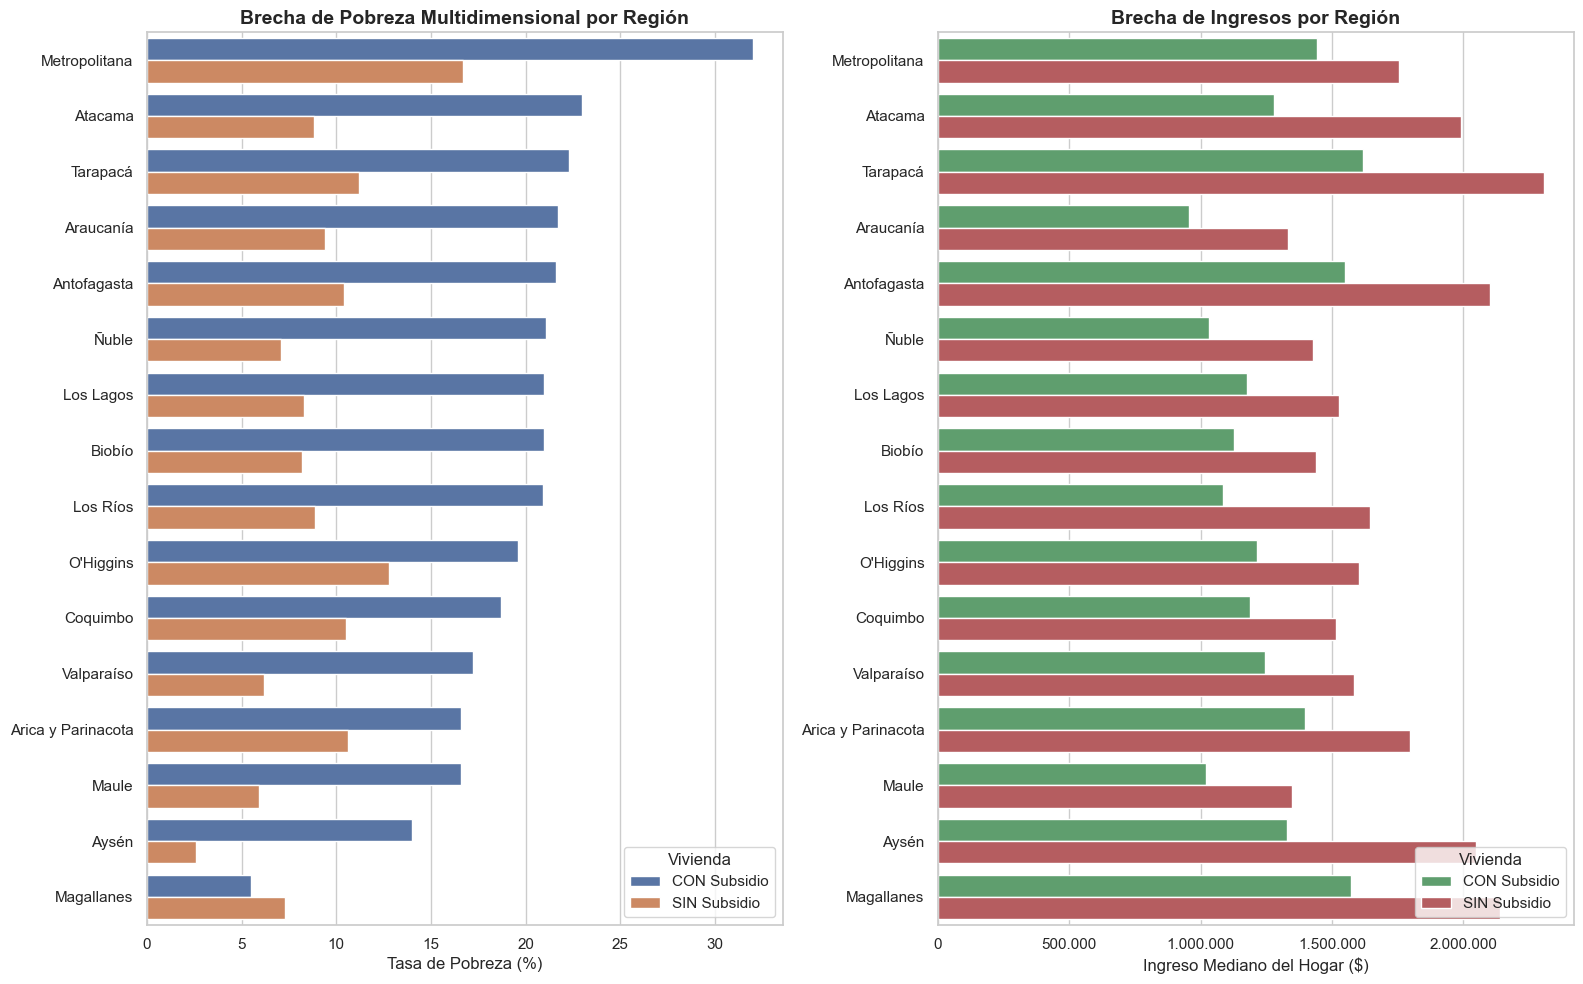

In [21]:
# --- CELDA 12: GRÁFICOS DE IMPACTO REGIONAL (EL MAPA DEL SUBSIDIO) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Generando panel gráfico regional...")

# 1. TRUCO NINJA ANTI-PYARROW: Pasamos de Polars -> Diccionario Python -> Pandas
datos_diccionario = df_final.to_dicts()
df_grafico = pd.DataFrame(datos_diccionario)

# 2. Ordenamos el dataframe para que el gráfico quede ordenado (Ej: De norte a sur, o por pobreza)
# Aquí lo ordenamos por Pobreza de mayor a menor para que los casos críticos queden arriba
df_grafico = df_grafico.sort_values(by="Pobreza_%", ascending=False)

# 3. Configuramos un lienzo grande para que quepan las 16 regiones sin amontonarse
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 10)) # Lienzo más alto (10)

# --- GRÁFICO IZQUIERDO: POBREZA MULTIDIMENSIONAL ---
sns.barplot(
    data=df_grafico,
    y='Nombre_Region',
    x='Pobreza_%',
    hue='Situacion_Vivienda',
    ax=axes[0],
    palette=['#4C72B0', '#DD8452'] # Azul y Naranja clásico
)
axes[0].set_title('Brecha de Pobreza Multidimensional por Región', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tasa de Pobreza (%)', fontsize=12)
axes[0].set_ylabel('')
axes[0].legend(title='Vivienda', loc='lower right')

# --- GRÁFICO DERECHO: INGRESOS MEDIANOS ---
sns.barplot(
    data=df_grafico,
    y='Nombre_Region',
    x='Ingreso_Mediano',
    hue='Situacion_Vivienda',
    ax=axes[1],
    palette=['#55A868', '#C44E52'] # Verde y Rojo suave
)
axes[1].set_title('Brecha de Ingresos por Región', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ingreso Mediano del Hogar ($)', fontsize=12)
axes[1].set_ylabel('')
# Formateamos el eje X para que los millones se lean mejor
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', '.')))
axes[1].legend(title='Vivienda', loc='lower right')

# Ajustes finales
plt.tight_layout()
plt.show()

In [22]:
# --- CELDA MAESTRA: METODOLOGÍA OFICIAL CASEN (HOGARES + EXPANSIÓN) ---
import polars as pl

print("Aplicando limpieza metodológica CASEN (Reglas de Hogar y Expansión)...\n")

# 1. REGLA DEL HOGAR: Filtramos SOLO a los Jefes de Hogar para analizar ingresos y vivienda
# Así evitamos contar el mismo ingreso de la casa múltiples veces
df_hogares = df.filter(pl.col("id_persona") == 1)

# 2. REGLA DEL FACTOR DE EXPANSIÓN: Calculamos los promedios ponderados por 'expr'
# Fórmula del promedio ponderado: Suma(Valor * expr) / Suma(expr)
resumen_limpio = df_hogares.group_by("region").agg([
    # Cantidad de HOGARES que representan en la vida real
    pl.col("expr").sum().alias("Total_Hogares_Reales"),
    
    # Ingreso Promedio Ponderado (El oficial)
    ((pl.col("ytotcorh") * pl.col("expr")).sum() / pl.col("expr").sum()).round(0).alias("Ingreso_Promedio_Oficial"),
    
    # Tasa de Pobreza Multidimensional Ponderada Oficial
    (((pl.col("pobreza_multi") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Pobreza_Multi_Oficial_%")
]).sort("Pobreza_Multi_Oficial_%", descending=True)

# Diccionario de regiones
dicc_regiones = {
    1: 'Tarapacá', 2: 'Antofagasta', 3: 'Atacama', 4: 'Coquimbo',
    5: 'Valparaíso', 6: 'O\'Higgins', 7: 'Maule', 8: 'Biobío',
    9: 'Araucanía', 10: 'Los Lagos', 11: 'Aysén', 12: 'Magallanes',
    13: 'Metropolitana', 14: 'Los Ríos', 15: 'Arica y Parinacota', 16: 'Ñuble'
}

# Aplicamos los nombres
resumen_limpio = resumen_limpio.with_columns(
    pl.col("region").map_elements(lambda x: dicc_regiones.get(x, "N/A"), return_dtype=pl.String).alias("Region_Nombre")
).select(["Region_Nombre", "Total_Hogares_Reales", "Ingreso_Promedio_Oficial", "Pobreza_Multi_Oficial_%"])

print(resumen_limpio)

Aplicando limpieza metodológica CASEN (Reglas de Hogar y Expansión)...

shape: (16, 4)
┌────────────────────┬──────────────────────┬──────────────────────────┬─────────────────────────┐
│ Region_Nombre      ┆ Total_Hogares_Reales ┆ Ingreso_Promedio_Oficial ┆ Pobreza_Multi_Oficial_% │
│ ---                ┆ ---                  ┆ ---                      ┆ ---                     │
│ str                ┆ i64                  ┆ f64                      ┆ f64                     │
╞════════════════════╪══════════════════════╪══════════════════════════╪═════════════════════════╡
│ Tarapacá           ┆ 128905               ┆ 1.761434e6               ┆ 16.8                    │
│ Atacama            ┆ 110249               ┆ 1.64332e6                ┆ 14.7                    │
│ Metropolitana      ┆ 2926333              ┆ 2.297632e6               ┆ 14.4                    │
│ Arica y Parinacota ┆ 85324                ┆ 1.556864e6               ┆ 14.1                    │
│ O'Higgins          ┆

Generando gráficos con la metodología oficial CASEN...


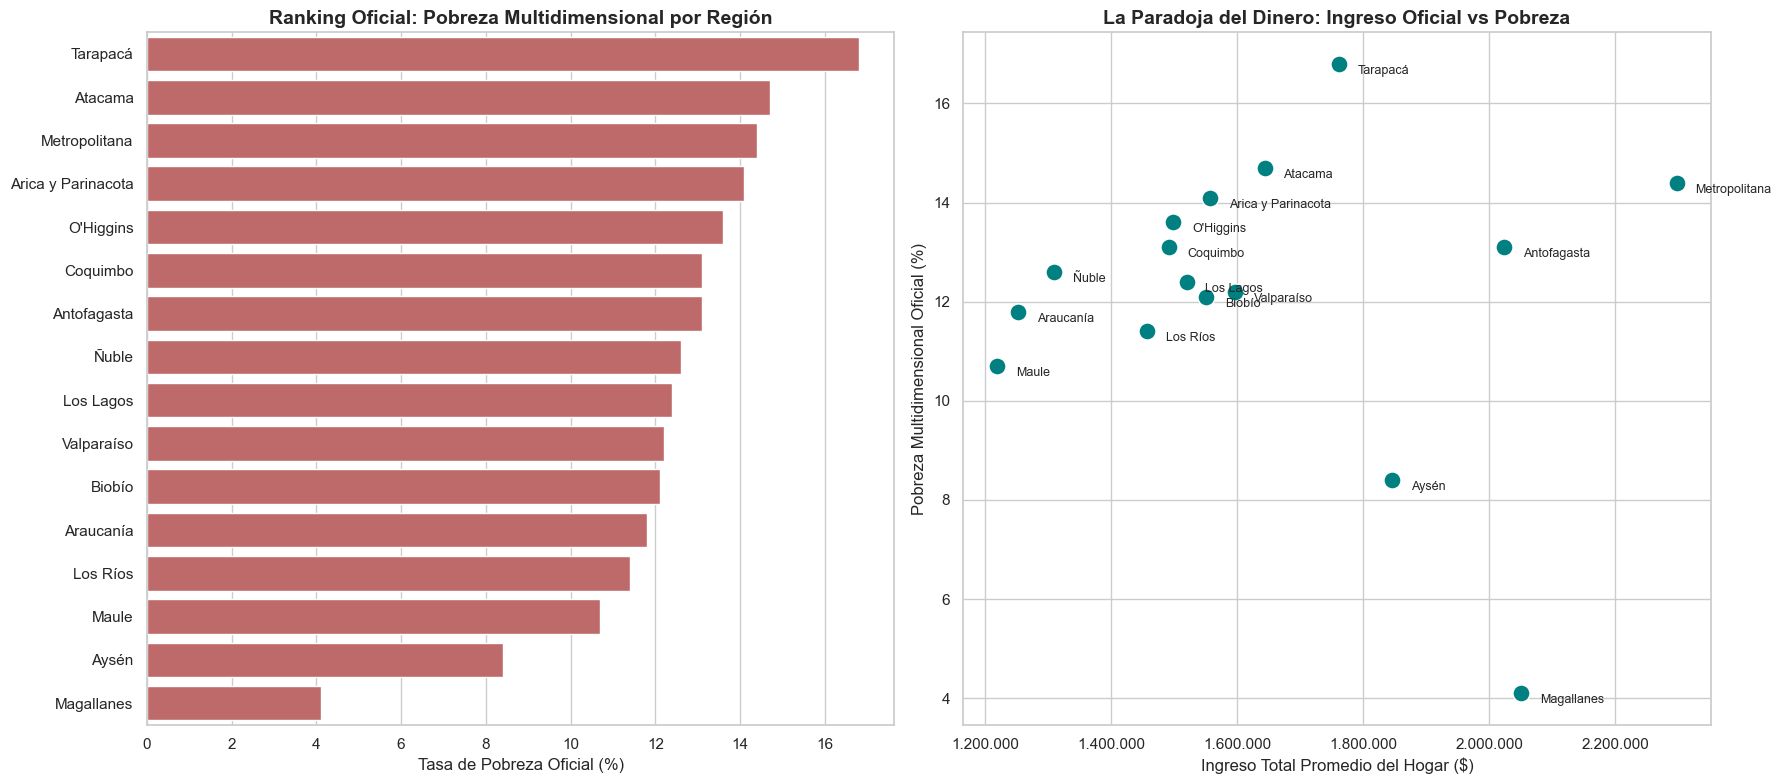

In [23]:
# --- CELDA 13: VISUALIZACIÓN OFICIAL (POBREZA E INGRESOS CORREGIDOS) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Generando gráficos con la metodología oficial CASEN...")

# 1. Pasamos el resumen limpio a Pandas usando nuestro truco de diccionarios
df_grafico_oficial = pd.DataFrame(resumen_limpio.to_dicts())

# Ordenamos por pobreza para el gráfico de barras
df_grafico_oficial = df_grafico_oficial.sort_values(by="Pobreza_Multi_Oficial_%", ascending=False)

# 2. Configuramos el lienzo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- GRÁFICO 1: Ranking Oficial de Pobreza ---
sns.barplot(
    data=df_grafico_oficial,
    x='Pobreza_Multi_Oficial_%',
    y='Region_Nombre',
    ax=axes[0],
    color='indianred'
)
axes[0].set_title('Ranking Oficial: Pobreza Multidimensional por Región', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tasa de Pobreza Oficial (%)', fontsize=12)
axes[0].set_ylabel('')

# --- GRÁFICO 2: Dispersión (Ingreso vs Pobreza) ---
sns.scatterplot(
    data=df_grafico_oficial,
    x='Ingreso_Promedio_Oficial',
    y='Pobreza_Multi_Oficial_%',
    ax=axes[1],
    color='teal',
    s=150 # Tamaño de los puntos
)

# Agregamos los nombres de las regiones a los puntos
for i in range(df_grafico_oficial.shape[0]):
    axes[1].text(
        df_grafico_oficial['Ingreso_Promedio_Oficial'].iloc[i] + 30000, # Ajuste para que el texto no tape el punto
        df_grafico_oficial['Pobreza_Multi_Oficial_%'].iloc[i] - 0.2, 
        df_grafico_oficial['Region_Nombre'].iloc[i], 
        fontsize=9
    )

axes[1].set_title('La Paradoja del Dinero: Ingreso Oficial vs Pobreza', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ingreso Total Promedio del Hogar ($)', fontsize=12)
axes[1].set_ylabel('Pobreza Multidimensional Oficial (%)', fontsize=12)

# Formateamos el eje X para que los números grandes se lean fácil (ej: 1.500.000)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', '.')))

plt.tight_layout()
plt.show()

Calculando el impacto del subsidio con expansiones oficiales...



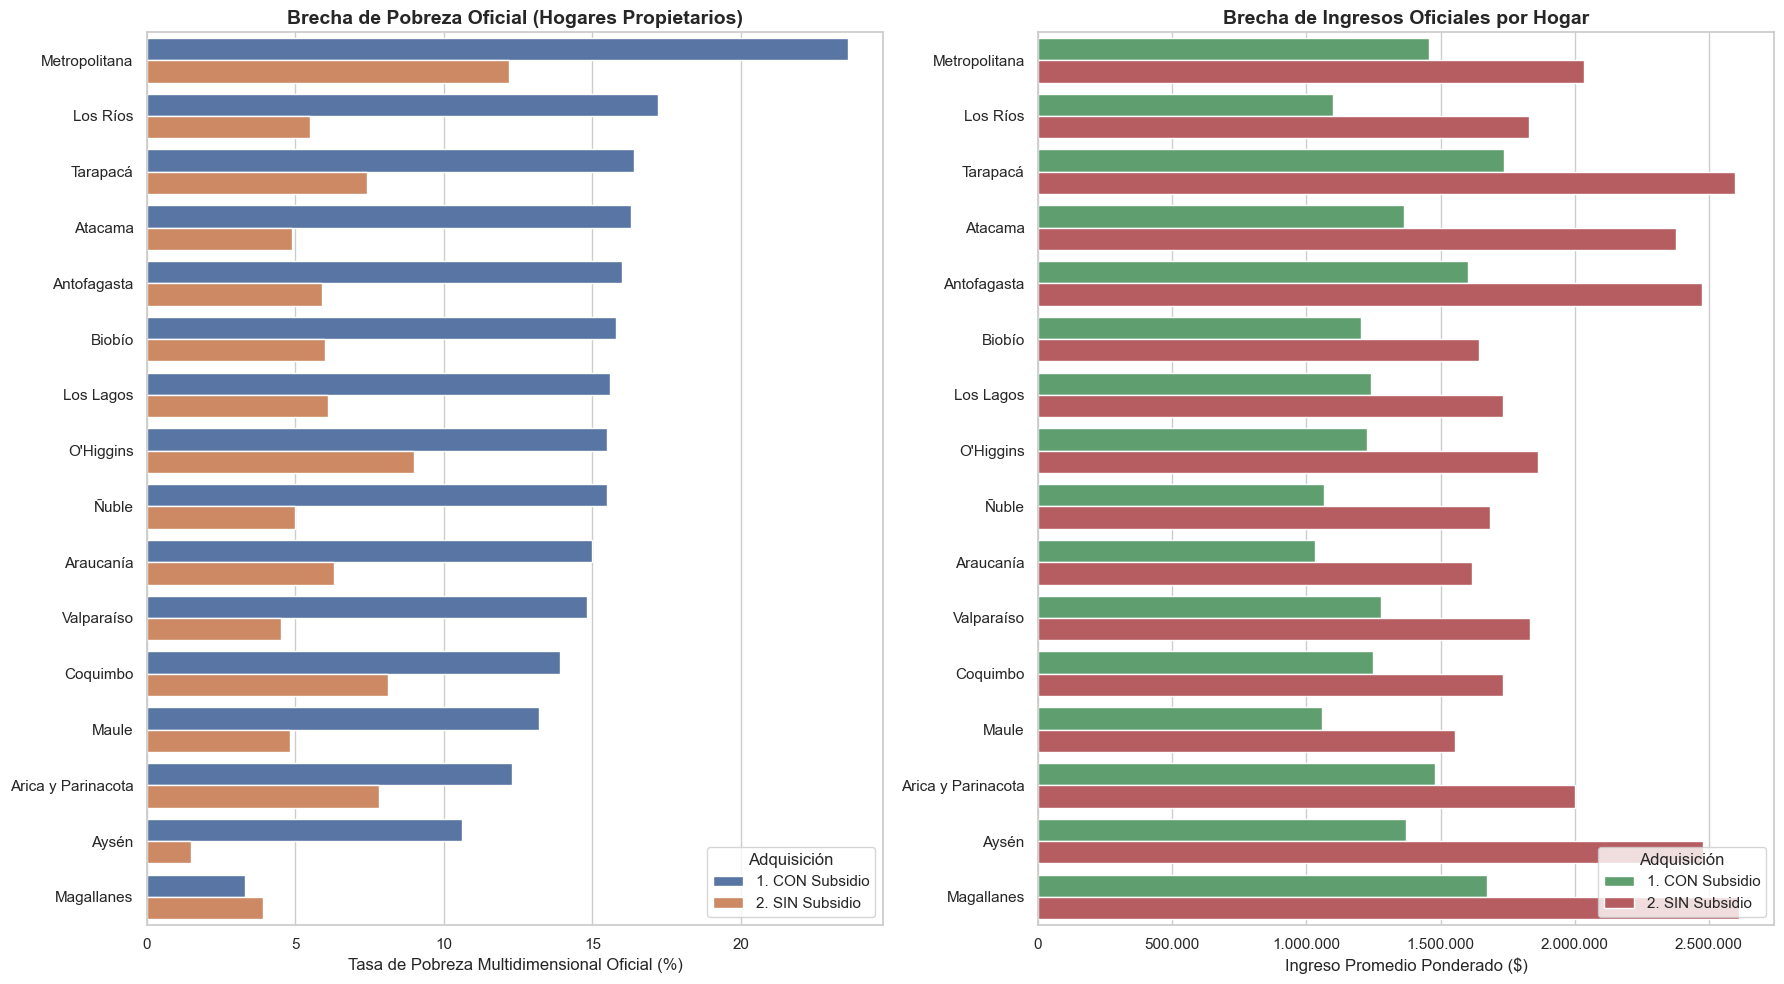


--- DATOS OFICIALES: REGIÓN METROPOLITANA ---
Situacion_Vivienda  Hogares_Reales_Representados  Pobreza_Oficial_%  Ingreso_Promedio_Oficial
   1. CON Subsidio                        248380               23.6                 1455087.0
   2. SIN Subsidio                        388068               12.2                 2035853.0


In [24]:
# --- CELDA 14: LA PARADOJA DEL SUBSIDIO (METODOLOGÍA OFICIAL CASEN) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import polars as pl

print("Calculando el impacto del subsidio con expansiones oficiales...\n")

# 1. FILTROS RIGUROSOS: Jefe de Hogar (1) + Propietarios (v13: 1 o 2) + Respondieron Subsidio (v15: 1 o 2)
df_oficial_sub = df.filter(
    (pl.col("id_persona") == 1) & 
    (pl.col("v13").is_in([1, 2])) & 
    (pl.col("v15").is_in([1, 2]))
)

# 2. CÁLCULO PONDERADO (REGLA DE ORO)
resumen_sub_oficial = df_oficial_sub.group_by(["region", "v15"]).agg([
    # Cuántos hogares reales representa esto en Chile
    pl.col("expr").sum().alias("Hogares_Reales_Representados"),
    
    # Pobreza Multidimensional Ponderada
    (((pl.col("pobreza_multi") * pl.col("expr")).sum() / pl.col("expr").sum()) * 100).round(1).alias("Pobreza_Oficial_%"),
    
    # Ingreso Ponderado
    ((pl.col("ytotcorh") * pl.col("expr")).sum() / pl.col("expr").sum()).round(0).alias("Ingreso_Promedio_Oficial")
])

# 3. DICCIONARIOS Y LIMPIEZA
dicc_regiones = {
    1: 'Tarapacá', 2: 'Antofagasta', 3: 'Atacama', 4: 'Coquimbo',
    5: 'Valparaíso', 6: 'O\'Higgins', 7: 'Maule', 8: 'Biobío',
    9: 'Araucanía', 10: 'Los Lagos', 11: 'Aysén', 12: 'Magallanes',
    13: 'Metropolitana', 14: 'Los Ríos', 15: 'Arica y Parinacota', 16: 'Ñuble'
}

resumen_sub_oficial = resumen_sub_oficial.with_columns([
    pl.col("region").map_elements(lambda x: dicc_regiones.get(x, "N/A"), return_dtype=pl.String).alias("Nombre_Region"),
    pl.when(pl.col("v15") == 1).then(pl.lit("1. CON Subsidio")).otherwise(pl.lit("2. SIN Subsidio")).alias("Situacion_Vivienda")
])

# 4. PASAMOS A PANDAS PARA GRAFICAR (Truco Ninja)
df_grafico = pd.DataFrame(resumen_sub_oficial.to_dicts())

# Ordenamos por región para que el gráfico tenga sentido geográfico / magnitud
# (Vamos a ordenarlo por la pobreza de los que SÍ tienen subsidio)
orden_regiones = df_grafico[df_grafico['Situacion_Vivienda'] == '1. CON Subsidio'].sort_values(by="Pobreza_Oficial_%", ascending=False)['Nombre_Region'].tolist()
df_grafico['Nombre_Region'] = pd.Categorical(df_grafico['Nombre_Region'], categories=orden_regiones, ordered=True)
df_grafico = df_grafico.sort_values(by=['Nombre_Region', 'Situacion_Vivienda'])

# 5. CREACIÓN DEL PANEL DE GRÁFICOS
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# --- GRÁFICO IZQUIERDO: Brecha de Pobreza Oficial ---
sns.barplot(
    data=df_grafico,
    y='Nombre_Region',
    x='Pobreza_Oficial_%',
    hue='Situacion_Vivienda',
    ax=axes[0],
    palette=['#4C72B0', '#DD8452'] # Azul y Naranja
)
axes[0].set_title('Brecha de Pobreza Oficial (Hogares Propietarios)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tasa de Pobreza Multidimensional Oficial (%)', fontsize=12)
axes[0].set_ylabel('')
axes[0].legend(title='Adquisición', loc='lower right')

# --- GRÁFICO DERECHO: Brecha de Ingresos Oficial ---
sns.barplot(
    data=df_grafico,
    y='Nombre_Region',
    x='Ingreso_Promedio_Oficial',
    hue='Situacion_Vivienda',
    ax=axes[1],
    palette=['#55A868', '#C44E52'] # Verde y Rojo
)
axes[1].set_title('Brecha de Ingresos Oficiales por Hogar', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ingreso Promedio Ponderado ($)', fontsize=12)
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(',', '.')))
axes[1].legend(title='Adquisición', loc='lower right')

plt.tight_layout()
plt.show()

# Imprimimos la tabla resumen de la RM para que tengas el dato exacto a mano
print("\n--- DATOS OFICIALES: REGIÓN METROPOLITANA ---")
rm_data = df_grafico[df_grafico['Nombre_Region'] == 'Metropolitana'][['Situacion_Vivienda', 'Hogares_Reales_Representados', 'Pobreza_Oficial_%', 'Ingreso_Promedio_Oficial']]
print(rm_data.to_string(index=False))